Project 2: Exploratory Data Analysis (EDA)
Lagos Healthcare Dataset

importing pandas and load cleaned dataset from Project 1 into a DatFrame(df)for analysis.

In [ ]:
import pandas as pd

In [2]:
df = pd.read_csv('healthcare_cleaned.csv')

Previewing the first few rows of the data.

In [3]:
df.head()

,Patient_ID,Age,Gender,BMI,Admission_Date,Admission_Type,Diagnosis,Systolic_BP,Diastolic_BP,Glucose_Level,Cholesterol,Hemoglobin,Medication,Smoking_Status,Insurance_Type,Length_of_Stay_Days,Doctor_ID,Hospital,Readmission,Outcome
0,P13751,60,Male,25.9,2018-08-10,Urgent,Diabetes Type 2,126.0,73.0,106.3,165.9,12.8,Ibuprofen,Non-Smoker,Private,3,DR537,Metro Health Center,No,Improved
1,P12962,49,Male,28.5,2020-02-14,Emergency,Diabetes Type 2,120.0,69.0,77.0,212.0,11.7,Metformin,Never,Medicare,3,DR409,Metro Health Center,No,Improved
2,P83901,63,Male,31.9,2023-01-27,Emergency,Diabetes Type 2,102.0,85.0,68.7,211.6,14.4,Metformin,Smoker,Private,3,DR993,city general hospital,No,Discharged
3,P91953,79,Male,19.1,2019-09-14,Emergency,Coronary Artery Disease,116.0,74.0,66.6,179.0,14.7,Metoprolol,Non-Smoker,Medicaid,3,DR666,Metro Health Center,0,Discharged
4,P47430,47,Female,26.8,2023-09-01,Urgent,Coronary Artery Disease,120.0,76.0,103.4,187.7,13.3,Metoprolol,Smoker,Private,3,DR942,St. Mary Medical,No,TRANSFERRED


Checking the number of rows and columns in the dataset.

In [4]:
print(df.shape)

(9305, 20)


Checking the data types and non-null counts for each column.

In [5]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9305 entries, 0 to 9304
Data columns (total 20 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Patient_ID           9305 non-null   object 
 1   Age                  9305 non-null   int64  
 2   Gender               9305 non-null   object 
 3   BMI                  9305 non-null   float64
 4   Admission_Date       9305 non-null   object 
 5   Admission_Type       9305 non-null   object 
 6   Diagnosis            9305 non-null   object 
 7   Systolic_BP          9305 non-null   float64
 8   Diastolic_BP         9305 non-null   float64
 9   Glucose_Level        9305 non-null   float64
 10  Cholesterol          9305 non-null   float64
 11  Hemoglobin           9305 non-null   float64
 12  Medication           9305 non-null   object 
 13  Smoking_Status       9305 non-null   object 
 14  Insurance_Type       9305 non-null   object 
 15  Length_of_Stay_Days  9305 non-null   i

Checking the descriptive statistics(mean, median, min, max) and spread(count, std, percentiles) of all numerical columns.

In [6]:
df.describe()

,Age,BMI,Systolic_BP,Diastolic_BP,Glucose_Level,Cholesterol,Hemoglobin,Length_of_Stay_Days
count,9305.000000,9305.000000,9305.000000,9305.000000,9305.000000,9305.000000,9305.000000,9305.0
mean,51.465019,28.509952,121.022354,76.363568,106.634788,178.934573,13.491725,3.0
std,17.947577,5.728255,17.369695,9.668089,24.717042,34.355314,1.738943,0.0
min,1.000000,12.000000,55.000000,31.000000,8.300000,65.600000,6.400000,3.0
25%,39.000000,24.800000,111.000000,70.000000,91.500000,157.200000,12.400000,3.0
50%,51.000000,28.500000,120.000000,76.000000,106.300000,179.000000,13.500000,3.0
75%,64.000000,32.200000,129.000000,83.000000,121.600000,200.300000,14.600000,3.0
max,100.000000,53.100000,250.000000,110.000000,211.300000,309.000000,20.200000,3.0


Checking the amount of records that falls into each category for Gender, Diagnosis and Admission Type

In [7]:
print(df['Gender'].value_counts())
print(df['Diagnosis'].value_counts())
print(df['Admission_Type'].value_counts())

Gender
Female    4978
Male      4327
Name: count, dtype: int64
Diagnosis
Diabetes Type 2            1864
Hypertension               1246
Coronary Artery Disease    1008
Copd                        982
Arthritis                   951
Depression                  606
Dementia                    364
Heart Failure               339
Stroke                      335
Flu                         333
Fracture                    316
Asthma                      313
Anxiety                     305
Migraine                    248
Anemia                       52
Appendicitis                 43
Name: count, dtype: int64
Admission_Type
Emergency    3844
Elective     3042
Urgent       2419
Name: count, dtype: int64


Flagging unusually high or low values in Systolic_BP using the IQR metod.

In [8]:
Q1 = df['Systolic_BP'].quantile(0.25)
Q3 = df['Systolic_BP'].quantile(0.75)
IQR = Q3 - Q1
outliers = df[(df['Systolic_BP'] < Q1 - 1.5*IQR) | (df['Systolic_BP'] > Q3 + 1.5*IQR)]
print(f"Number of Systolic_BP outliers: {len(outliers)}")

Number of Systolic_BP outliers: 201


Flagging unusually high or low values in Diastolic_BP, BMI, Cholesterol and Glucose_Level using the IQR metod.

In [9]:
for col in ['Diastolic_BP', 'BMI', 'Cholesterol', 'Glucose_Level']:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = df[(df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)]
    print(f"Number of {col} outliers: {len(outliers)}")

Number of Diastolic_BP outliers: 83
Number of BMI outliers: 104
Number of Cholesterol outliers: 132
Number of Glucose_Level outliers: 177


Previewing Hemoglobin valuesg to confirm they are numeric before using them in correlation analysis.

In [10]:
df['Hemoglobin'].head(10)

0    12.8
1    11.7
2    14.4
3    14.7
4    13.3
5    15.5
6    16.6
7    14.0
8    10.1
9    12.4
Name: Hemoglobin, dtype: float64

Checking how strongly each numeric variable relates to others using Pearson correlation(values close to 0 = weak/no relationship).

In [11]:
numeric_cols = ['Age','BMI','Systolic_BP','Diastolic_BP','Glucose_Level','Cholesterol','Hemoglobin','Length_of_Stay_Days']

correlation_matrix = df[numeric_cols].corr()
print(correlation_matrix)

                          Age       BMI  Systolic_BP  Diastolic_BP  \
Age                  1.000000  0.093319     0.082022      0.062999   
BMI                  0.093319  1.000000     0.023699     -0.003592   
Systolic_BP          0.082022  0.023699     1.000000      0.009996   
Diastolic_BP         0.062999 -0.003592     0.009996      1.000000   
Glucose_Level       -0.013114  0.094636     0.011175      0.006584   
Cholesterol          0.045623  0.016691     0.000605     -0.005260   
Hemoglobin           0.005243  0.007003    -0.008274     -0.001115   
Length_of_Stay_Days       NaN       NaN          NaN           NaN   

                     Glucose_Level  Cholesterol  Hemoglobin  \
Age                      -0.013114     0.045623    0.005243   
BMI                       0.094636     0.016691    0.007003   
Systolic_BP               0.011175     0.000605   -0.008274   
Diastolic_BP              0.006584    -0.005260   -0.001115   
Glucose_Level             1.000000     0.004618   -0.0

Checking the data type and first few values of Lenght of Stay Days to check why it returned NaN in the correlation matrix.

In [12]:
print(df['Length_of_Stay_Days'].dtypes)
print(df['Length_of_Stay_Days'].head(10))

int64
0    3
1    3
2    3
3    3
4    3
5    3
6    3
7    3
8    3
9    3
Name: Length_of_Stay_Days, dtype: int64


Checking the spread and unique values of Lenght of Stay Days to see if it varies across records.

In [13]:
print(df['Length_of_Stay_Days'].describe())
print(df['Length_of_Stay_Days'].unique())

count    9305.0
mean        3.0
std         0.0
min         3.0
25%         3.0
50%         3.0
75%         3.0
max         3.0
Name: Length_of_Stay_Days, dtype: float64
[3]


Rechecking the correlation matrix without Length of Stay Days since it had no variation across records.

In [15]:
numeric_cols = ['Age','BMI','Systolic_BP','Diastolic_BP','Glucose_Level','Cholesterol','Hemoglobin']

correlation_matrix = df[numeric_cols].corr()
print(correlation_matrix)

                    Age       BMI  Systolic_BP  Diastolic_BP  Glucose_Level  \
Age            1.000000  0.093319     0.082022      0.062999      -0.013114   
BMI            0.093319  1.000000     0.023699     -0.003592       0.094636   
Systolic_BP    0.082022  0.023699     1.000000      0.009996       0.011175   
Diastolic_BP   0.062999 -0.003592     0.009996      1.000000       0.006584   
Glucose_Level -0.013114  0.094636     0.011175      0.006584       1.000000   
Cholesterol    0.045623  0.016691     0.000605     -0.005260       0.004618   
Hemoglobin     0.005243  0.007003    -0.008274     -0.001115      -0.003621   

               Cholesterol  Hemoglobin  
Age               0.045623    0.005243  
BMI               0.016691    0.007003  
Systolic_BP       0.000605   -0.008274  
Diastolic_BP     -0.005260   -0.001115  
Glucose_Level     0.004618   -0.003621  
Cholesterol       1.000000    0.009105  
Hemoglobin        0.009105    1.000000  


Importing seaborn and matplotlib for visualizing the correlation matrix as a heatmap to make patterns easier to spot at a glance.

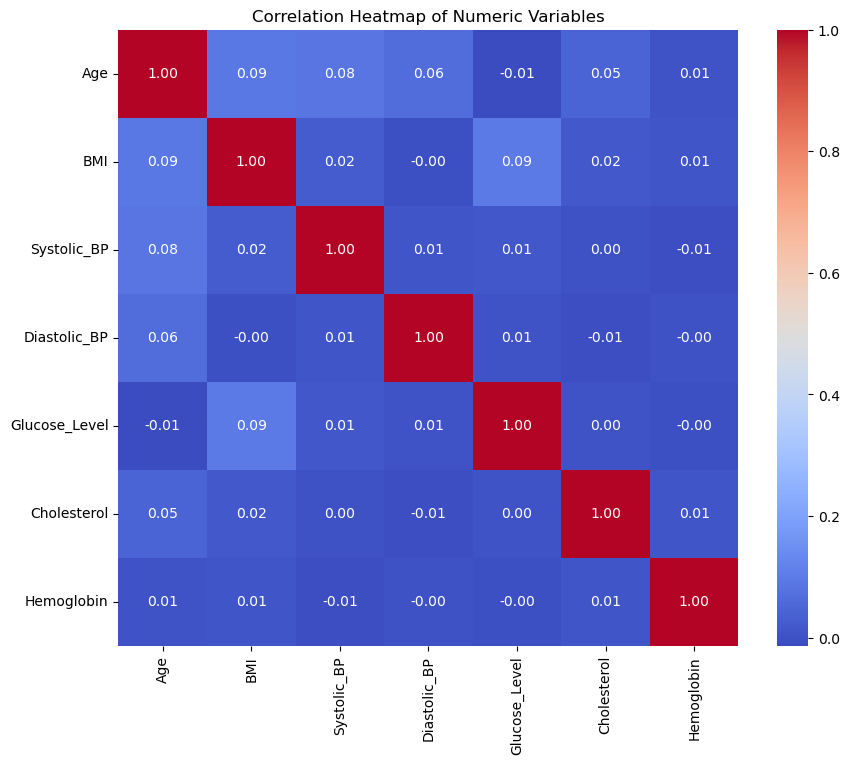

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize = (10,8))
sns.heatmap(correlation_matrix, annot = True, cmap='coolwarm',fmt='.2f')
plt.title('Correlation Heatmap of Numeric Variables')
plt.show()

Importing matplotlib for visualizing the spread and outliers of BMI, Systolic_BP, Diastolic_BP, Cholesterol and Glucose_Level using boxplots.

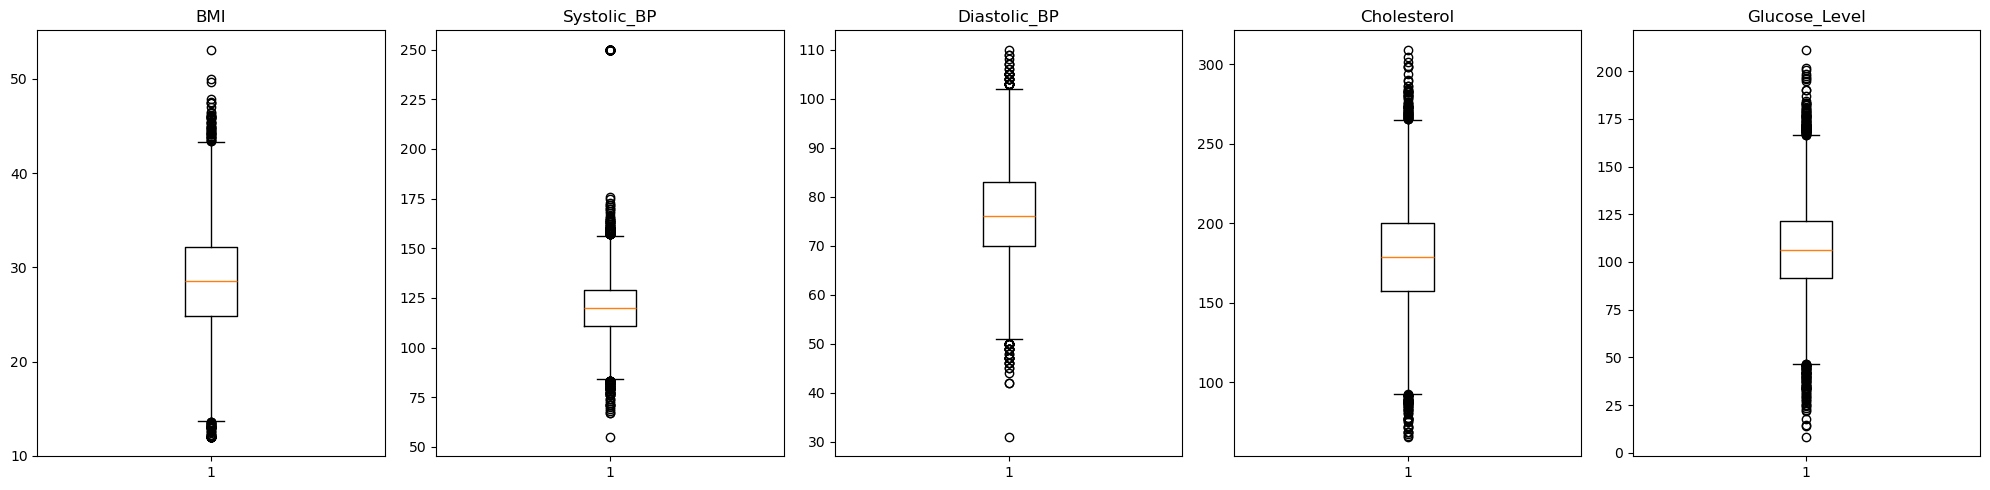

In [19]:
import matplotlib.pyplot as plt

cols = ['BMI','Systolic_BP','Diastolic_BP','Cholesterol','Glucose_Level']

fig, axes = plt.subplots(1,5, figsize=(20,5))

for i,col in enumerate(cols):
    axes[i].boxplot(df[col])
    axes[i].set_title(col)

plt.tight_layout()
plt.show()

Visualizing the means distribution shape of BMI, Systolic BP, Diastolic BP, Cholesterol and Glucose Level.

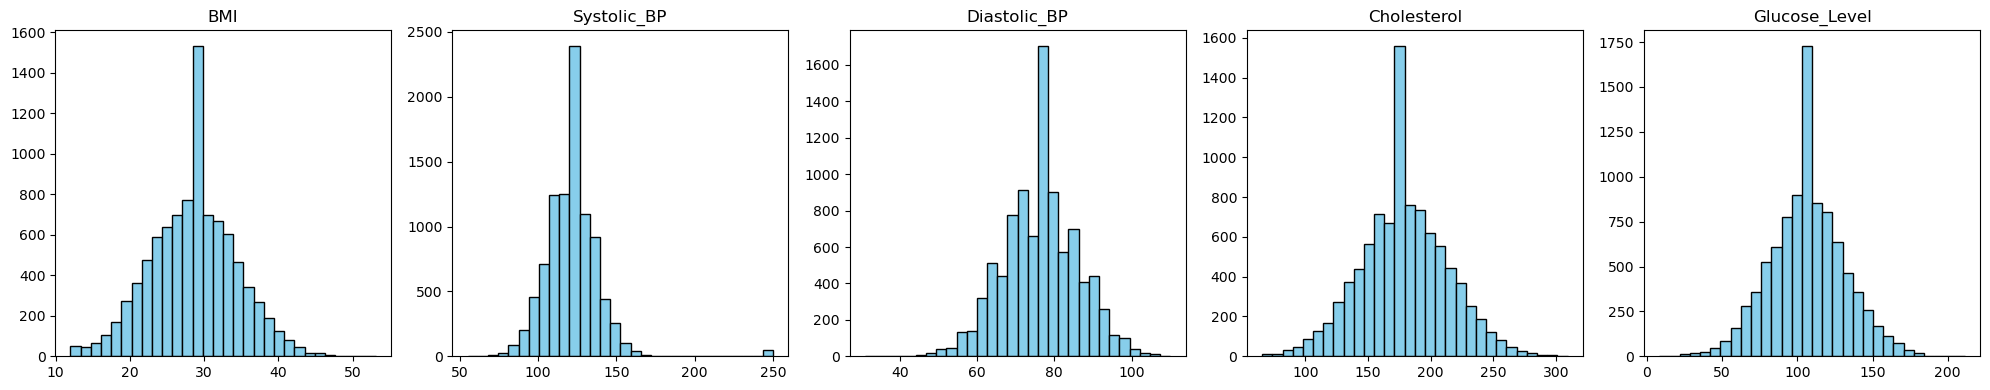

In [20]:
fig, axes = plt.subplots(1,5, figsize=(20,4))

for i, col in enumerate(cols):
    axes[i].hist(df[col], bins=30, color='skyblue',edgecolor='black')
    axes[i].set_title(col)

plt.tight_layout()
plt.show()

Comparing average BMI, blood pressure, glucose and Cholestrol across different diagnoses to spot patterns.

In [21]:
group_means = df.groupby('Diagnosis')[['BMI','Systolic_BP','Diastolic_BP','Glucose_Level','Cholesterol']].mean().round(2)
print(group_means)

                           BMI  Systolic_BP  Diastolic_BP  Glucose_Level  \
Diagnosis                                                                  
Anemia                   26.93       119.79         74.29         105.47   
Anxiety                  27.75       119.41         76.43         106.05   
Appendicitis             28.12       117.07         74.84         104.87   
Arthritis                28.56       122.21         76.32         103.04   
Asthma                   27.81       118.48         75.21         105.81   
Copd                     28.54       121.22         76.84         104.15   
Coronary Artery Disease  28.56       122.00         76.42         105.03   
Dementia                 28.85       122.72         76.66         102.67   
Depression               28.50       120.54         76.41         103.95   
Diabetes Type 2          28.58       121.15         76.39         115.32   
Flu                      27.85       118.95         75.36         105.47   
Fracture    

Comparing average BMI, blood pressure, glucose and cholesterol across outcome categories.

In [22]:
outcome_means = df.groupby('Outcome')[['BMI','Systolic_BP','Diastolic_BP','Glucose_Level','Cholesterol']].mean().round(2)
print(outcome_means)

               BMI  Systolic_BP  Diastolic_BP  Glucose_Level  Cholesterol
Outcome                                                                  
DECEASED     28.31       119.88         77.88         110.91       178.13
DISCHARGED   28.54       120.38         76.52         106.51       176.61
Deceased     28.46       122.46         76.07         106.39       178.22
Discharged   28.57       120.93         76.46         106.78       178.64
IMPROVED     27.93       119.56         74.45         106.46       184.24
Improved     28.42       121.11         76.26         106.64       179.53
TRANSFERRED  28.01       121.96         75.92         107.71       186.92
Transferred  28.43       120.91         76.24         106.03       179.52


Fixing the inconsistent capitalization in the Outcome categories.

In [25]:
df['Outcome'] = df['Outcome'].str.title()
print(df['Outcome'].value_counts())

Outcome
Discharged     5733
Improved       1709
Transferred    1354
Deceased        509
Name: count, dtype: int64


Re-running the comparison with the standardized Outcome categories to check  

In [26]:
outcome_means = df.groupby('Outcome')[['BMI','Systolic_BP','Diastolic_BP','Glucose_Level','Cholesterol']].mean().round(2)
print(outcome_means)

               BMI  Systolic_BP  Diastolic_BP  Glucose_Level  Cholesterol
Outcome                                                                  
Deceased     28.46       122.38         76.13         106.54       178.22
Discharged   28.57       120.91         76.47         106.77       178.56
Improved     28.40       121.05         76.19         106.63       179.71
Transferred  28.41       120.95         76.23         106.10       179.80


Summary of Findings
BMI, Systolic_BP, Diastolic_BP, Cholesterol and Glucose Level are all right skewed with outliers and the correlation mahtrix shows no strong linear relationships between the numeric health variables. Cholesterol stands out as the most differenciated variable by Diagnosis with coronary Artery Disease and Heart Failure showing the highest averages. Outcome groups(Discharged, Improved, Transferred, Deceased) show only small differences across the health metrics.
